# Phenomenological Forward Models

Theoretical fringe patterns for point sources and extended (solar-disk) sources, visualised against the observation geometry.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# -- local utilities ---------------------------------------------------------
sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    # constants
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    C_LIGHT_MS, OMEGA_EARTH_RAD_S, SIDEREAL_DAY_S,
    NCH_LAT_DEG, NCH_LON_DEG,
    NOMINAL_B_EW_M, BAD_CHANNELS,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
    # data loading
    load_processed_sun_chip_series,
    # geometry
    lst_deg, hour_angle_deg, hour_angle_rad,
    geometric_delay_s, sky_baseline_lambda,
    fringe_frequency_hz, fringe_period_s, x_coordinate,
    # fringe models
    FringeModelParams, SolarDiskParams, SunspotParams,
    point_source_visibility, point_source_fringes,
    uniform_disk_visibility_amplitude, uniform_disk_visibility_signed,
    uniform_disk_zeros, solar_visibility, fringe_envelope,
    # baseline fitting
    BaselineResult,
    fft_baseline_single_channel, fft_baseline_broadband,
    phase_slope_baseline_single_channel, phase_slope_baseline_broadband,
    lag_delay_single_capture, lag_delay_baseline_series,
    combined_baseline,
    # solar analysis
    SolarDiameterResult, SunspotDetection,
    extract_fringe_envelope, find_bessel_zeros_in_envelope,
    solar_diameter_from_zeros, fit_solar_diameter_bessel,
    detect_sunspot_anomalies, characterize_sunspot_flux,
    # plotting
    PRIMARY_COLOR, SECONDARY_COLOR, TERTIARY_COLOR, QUATERNARY_COLOR,
    NEUTRAL_COLOR, COMPONENT_COLORS,
    SCATTER_S_FINE, SCATTER_S_STANDARD,
    LW_FINE, LW_GUIDE, LW_STANDARD, LW_MODEL,
    MARKER_MS_SMALL,
    TEXTWIDTH_IN, TICK_SIZE,
)
from utils.plotter import (
    plot_fringe_model_comparison,
    plot_bessel_envelope_fit,
    plot_solar_diameter_summary,
    plot_sunspot_residuals,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


In [2]:
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
print(f"Found {len(chip_paths)} chip files:")
for p in chip_paths:
    print(f"  {p.name}")

chip_data = load_processed_sun_chip_series(chip_paths)

Found 3 chip files:
  sun_calibration_chip_00.npz
  sun_calibration_chip_01.npz
  sun_calibration_chip_02.npz


In [3]:
# -------------------------------------------------------------------
# Unpack raw arrays
# -------------------------------------------------------------------
captures   = chip_data.captures          # CaptureSeries
corr_raw   = captures.corr              # (N_cap, N_CH) complex — raw visibility
corr_std   = captures.corr_std          # (N_cap, N_CH) float  — per-channel uncertainty
F_SKY_GHZ  = chip_data.f_sky_ghz        # (N_CH,) sky frequency in GHz
DF_HZ      = chip_data.df_hz            # channel spacing in Hz

# Timing and coordinates (pre-computed in chip export)
unix_mid   = captures.unix_mid          # (N_cap,) midpoint timestamps
ha_deg_arr = chip_data.ha_deg
ha_rad_arr = np.deg2rad(ha_deg_arr)
sun_ra     = chip_data.sun_ra_deg       # (N_cap,) Sun RA in degrees
sun_dec    = chip_data.sun_dec_deg      # (N_cap,) Sun Dec in degrees

# Chip boundaries
chip_slices = chip_data.chip_slices
N_chips = len(chip_slices)

# Derived quantities
F_SKY_HZ     = F_SKY_GHZ * 1e9
dec_rad_mean = np.deg2rad(np.nanmean(sun_dec))
band_mask    = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
band_center_hz = np.mean(F_SKY_HZ[band_mask])

# -------------------------------------------------------------------
# Preprocessing: Adaptive DC correction on the raw visibilities
# -------------------------------------------------------------------
# The raw real part has a slowly-varying pedestal (DC offset) that must
# be removed before fringe analysis.  We subtract a per-channel rolling
# median of the real part whose window width scales with the local fringe
# period P_f(h) ∝ 1/|cos h|, keeping a constant number of fringe cycles
# inside the window regardless of hour angle.
from utils import adaptive_real_dc_correction

DC_N_PERIODS       = 3.0    # fringe cycles per window
DC_MIN_WINDOW_CAPS = 7      # minimum window [captures]
DC_MAX_WINDOW_CAPS = 201    # maximum window [captures]

dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=BAD_CHANNELS,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=DC_N_PERIODS,
    min_window_caps=DC_MIN_WINDOW_CAPS,
    max_window_caps=DC_MAX_WINDOW_CAPS,
)
corr_dc = dc_result.corr_dc  # (N_cap, N_CH) complex — DC-corrected, bad channels = NaN

print(f"Total captures:     {len(unix_mid)}")
print(f"Channels:           {len(F_SKY_GHZ)}  ({F_SKY_GHZ[0]:.3f} -- {F_SKY_GHZ[-1]:.3f} GHz)")
print(f"Analysis band:      {PLOT_BAND_GHZ[0]:.3f} -- {PLOT_BAND_GHZ[1]:.3f} GHz  ({band_mask.sum()} channels)")
print(f"Band centre:        {band_center_hz/1e9:.4f} GHz")
print(f"Mean Sun dec:       {np.rad2deg(dec_rad_mean):.3f} deg")
print(f"HA range:           {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Chips:              {N_chips}")
print(f"DC correction:      adaptive, {DC_N_PERIODS} periods/window, "
      f"clamp [{DC_MIN_WINDOW_CAPS}, {DC_MAX_WINDOW_CAPS}] caps")
for ci, wc in enumerate(dc_result.window_caps_chips):
    print(f"  Chip {ci}: window range {wc.min()}–{wc.max()} captures")
print(f"Bad channels:       {list(BAD_CHANNELS)}")

Total captures:     8226
Channels:           1024  (10.290 -- 10.540 GHz)
Analysis band:      10.415 -- 10.485 GHz  (287 channels)
Band centre:        10.4499 GHz
Mean Sun dec:       -0.083 deg
HA range:           -79.9 to 22.0 deg
Chips:              3
DC correction:      adaptive, 3.0 periods/window, clamp [7, 201] caps
  Chip 0: window range 17–43 captures
  Chip 1: window range 17–27 captures
  Chip 2: window range 17–31 captures
Bad channels:       [0, 256, 512, 768]


# Part III: Phenomenological Forward Models

Before fitting data, we build and visualise the theoretical predictions to develop intuition for the expected fringe behaviour.

## 3.1 Point-source fringe pattern

We first plot the expected fringe pattern for a point source at the Sun's declination, using the nominal 20 m EW baseline. This shows the quasi-sinusoidal oscillation whose frequency varies as $\cos h$.

/tmp/ipykernel_46292/4216067478.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


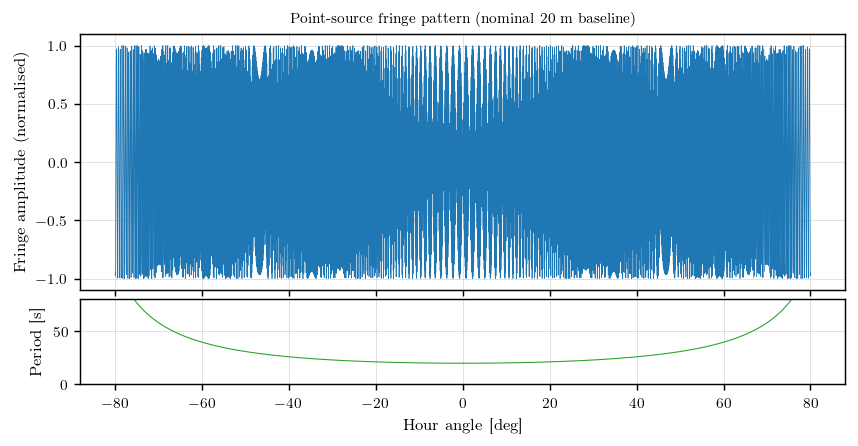

Fringe period at transit: 19.67 s


In [4]:
# --- Point-source fringe model over the full HA range ---
ha_model = np.linspace(-80, 80, 4000)  # degrees
ha_model_rad = np.deg2rad(ha_model)

params_pt = FringeModelParams(
    b_ew=NOMINAL_B_EW_M,
    b_ns=0.0,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    amplitude=1.0,
    phase_offset=0.0,
)

fringes_pt = point_source_fringes(ha_model_rad, params_pt)

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 3.5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

axes[0].plot(ha_model, fringes_pt, lw=0.4, color=PRIMARY_COLOR)
axes[0].set_ylabel("Fringe amplitude (normalised)")
axes[0].set_title("Point-source fringe pattern (nominal 20 m baseline)", fontsize=TICK_SIZE)

# Fringe frequency vs HA
ff = fringe_frequency_hz(ha_model_rad, dec_rad_mean, NOMINAL_B_EW_M, 0.0, band_center_hz)
axes[1].plot(ha_model, 1.0 / np.abs(ff), lw=LW_FINE, color=TERTIARY_COLOR)
axes[1].set_ylabel("Period [s]")
axes[1].set_xlabel("Hour angle [deg]")
axes[1].set_ylim(0, 80)
fig.tight_layout()
plt.show()

print(f"Fringe period at transit: {fringe_period_s(0.0, dec_rad_mean, NOMINAL_B_EW_M, 0.0, band_center_hz):.2f} s")

## 3.2 Bessel-function visibility envelope

The uniform-disk Bessel modulation $|2J_1(x)/x|$ shows how the fringe amplitude rises and falls as the projected baseline sweeps through the Bessel zeros during the observation. We plot this against the dimensionless argument $x = 2\pi |u| R$ and mark the predicted null locations.

/tmp/ipykernel_46292/524466467.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


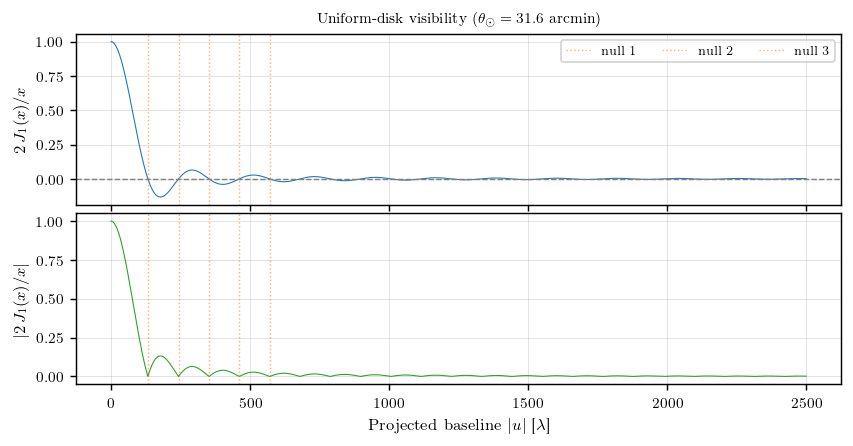

Predicted Bessel null baselines:
  Null 1: |u| = 132.7 wavelengths  (j_{1,1}/(2pi) = 0.6098)
  Null 2: |u| = 242.9 wavelengths  (j_{1,2}/(2pi) = 1.1166)
  Null 3: |u| = 352.3 wavelengths  (j_{1,3}/(2pi) = 1.6192)
  Null 4: |u| = 461.4 wavelengths  (j_{1,4}/(2pi) = 2.1205)
  Null 5: |u| = 570.4 wavelengths  (j_{1,5}/(2pi) = 2.6214)


In [5]:
# --- Bessel envelope: theoretical shape ---
R_nominal = np.deg2rad(SOLAR_DIAMETER_ARCMIN_NOMINAL / 2.0 / 60.0)  # angular radius [rad]
u_range = np.linspace(0, 2500, 5000)  # projected baseline in wavelengths

vis_signed = uniform_disk_visibility_signed(u_range, R_nominal)
vis_abs = uniform_disk_visibility_amplitude(u_range, R_nominal)

# Bessel zeros
bessel_uR = uniform_disk_zeros(5)
u_at_zeros = bessel_uR / R_nominal  # convert u*R -> u for this R

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 3.5), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1], "hspace": 0.05})

# Signed visibility
axes[0].plot(u_range, vis_signed, lw=LW_FINE, color=PRIMARY_COLOR)
axes[0].axhline(0, color=NEUTRAL_COLOR, lw=LW_GUIDE, ls="--")
for k, uz in enumerate(u_at_zeros):
    axes[0].axvline(uz, color=SECONDARY_COLOR, lw=LW_GUIDE, ls=":", alpha=0.6,
                    label=f"null {k+1}" if k < 3 else None)
axes[0].set_ylabel(r"$2\,J_1(x)/x$")
axes[0].set_title(
    rf"Uniform-disk visibility ($\theta_\odot = {SOLAR_DIAMETER_ARCMIN_NOMINAL:.1f}$ arcmin)",
    fontsize=TICK_SIZE,
)
axes[0].legend(fontsize=TICK_SIZE - 1, ncol=3)

# Absolute visibility
axes[1].plot(u_range, vis_abs, lw=LW_FINE, color=TERTIARY_COLOR)
for uz in u_at_zeros:
    axes[1].axvline(uz, color=SECONDARY_COLOR, lw=LW_GUIDE, ls=":", alpha=0.6)
axes[1].set_ylabel(r"$|2\,J_1(x)/x|$")
axes[1].set_xlabel(r"Projected baseline $|u|$ [$\lambda$]")

fig.tight_layout()
plt.show()

print("Predicted Bessel null baselines:")
for k, uz in enumerate(u_at_zeros):
    print(f"  Null {k+1}: |u| = {uz:.1f} wavelengths  (j_{{1,{k+1}}}/(2pi) = {bessel_uR[k]:.4f})")

## 3.3 Combined solar fringe model

The full predicted response for the Sun is the point-source fringe multiplied by the Bessel envelope. We plot this alongside the projected baseline track $|u|(h)$ to show where the Bessel nulls fall during our observation window.

/tmp/ipykernel_46292/1303586834.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


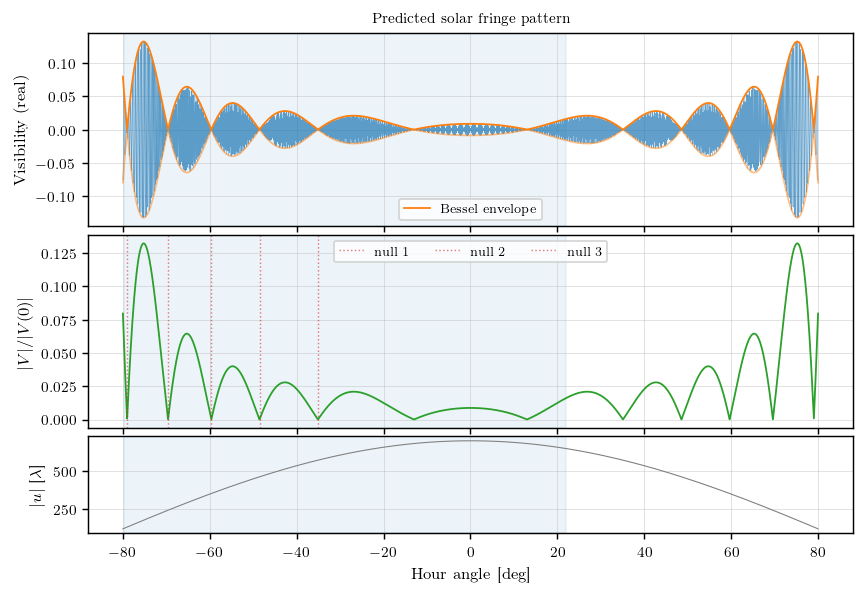

In [6]:
# --- Full solar fringe model ---
disk_params = SolarDiskParams(angular_radius_rad=R_nominal)
v_solar = solar_visibility(ha_model_rad, params_pt, disk_params)
env_model = fringe_envelope(ha_model_rad, params_pt, disk_params)

# Projected baseline track
u_track = sky_baseline_lambda(
    ha_model_rad, dec_rad_mean, NOMINAL_B_EW_M, 0.0, band_center_hz
)

fig, axes = plt.subplots(3, 1, figsize=(TEXTWIDTH_IN, 5.0), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1], "hspace": 0.05})

# (a) Solar fringes with envelope
axes[0].plot(ha_model, v_solar.real, lw=0.3, color=PRIMARY_COLOR, alpha=0.7)
axes[0].plot(ha_model, env_model, lw=LW_STANDARD, color=SECONDARY_COLOR, label="Bessel envelope")
axes[0].plot(ha_model, -env_model, lw=LW_STANDARD, color=SECONDARY_COLOR, alpha=0.5)
axes[0].set_ylabel("Visibility (real)")
axes[0].set_title("Predicted solar fringe pattern", fontsize=TICK_SIZE)
axes[0].legend(fontsize=TICK_SIZE - 1)

# (b) Bessel amplitude envelope only
axes[1].plot(ha_model, env_model, lw=LW_STANDARD, color=TERTIARY_COLOR)
for k, uz in enumerate(u_at_zeros):
    # Find HA where |u| = uz
    idx = np.argmin(np.abs(np.abs(u_track) - uz))
    if np.abs(u_track[idx]) > 0:
        axes[1].axvline(ha_model[idx], color=QUATERNARY_COLOR, lw=LW_GUIDE, ls=":",
                        alpha=0.6, label=f"null {k+1}" if k < 3 else None)
axes[1].set_ylabel(r"$|V|/|V(0)|$")
axes[1].legend(fontsize=TICK_SIZE - 1, ncol=3)

# (c) Projected baseline
axes[2].plot(ha_model, np.abs(u_track), lw=LW_FINE, color=NEUTRAL_COLOR)
axes[2].set_ylabel(r"$|u|$ [$\lambda$]")
axes[2].set_xlabel("Hour angle [deg]")

# Mark our HA observation range
for ax in axes:
    ax.axvspan(ha_deg_arr.min(), ha_deg_arr.max(), alpha=0.08, color=PRIMARY_COLOR)

fig.tight_layout()
plt.show()